# Bird Outbreak Activity vs Poultry Commodity Movement

## 1. Problem Statement

Build an analysis and prediction workflow to test whether bird outbreak activity helps explain or predict poultry-related commodity movement.

For this notebook version:

- **Historical commodity input:** the FAOSTAT extract in the repo root
- **Outbreak input:** the WAHIS event-level extract in the repo root
- **Target for v1:** **next-year percentage change in FAOSTAT chicken production**
- **Why this proxy:** the current FAOSTAT file does **not** contain price; it only contains yearly production volumes in tons

That means this notebook is intentionally framed as a solid outbreak-to-forecast prototype using the data you actually have now, with the target definition ready to swap to a true price series later.

In [1]:
from __future__ import annotations

import re
import unicodedata
from difflib import get_close_matches

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import Markdown, display
from sklearn.impute import SimpleImputer
from sklearn.linear_model import RidgeCV
from sklearn.metrics import mean_absolute_error, root_mean_squared_error
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from xgboost import XGBRegressor

pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 200)
plt.style.use("seaborn-v0_8-whitegrid")

TARGET_ITEM = "Meat of chickens, fresh or chilled"
TARGET_ELEMENT = "Production"
TEST_START_YEAR = 2019
OUTBREAK_REGEX = r"H\d+N\d+"

COUNTRY_ALIASES = {
    "bolivia plurinational state of": "bolivia",
    "brunei darussalam": "brunei",
    "china hong kong sar": "hong kong",
    "china mainland": "china peoples rep of",
    "czechia": "czech republic",
    "democratic peoples republic of korea": "korea dem peoples rep of",
    "iran islamic republic of": "iran",
    "lao peoples democratic republic": "laos",
    "moldova republic of": "moldova",
    "russian federation": "russia",
    "turkiye": "turkey",
    "united republic of tanzania": "tanzania",
    "venezuela bolivarian republic of": "venezuela",
    "viet nam": "vietnam",
}

OUTBREAK_FEATURE_COLUMNS = [
    "outbreak_count",
    "hxnx_subtype_count",
    "positive_lab_count",
    "species_diversity",
    "location_spread",
    "severity_index",
]

OUTBREAK_SAMPLE_COLUMNS = [
    "outbreak_id",
    "country",
    "disease_name",
    "subtype_disease_name",
    "location",
    "lab_test_id",
    "lab_species",
    "lab_result",
]


def country_key(value: str) -> str:
    if pd.isna(value):
        return ""
    text = unicodedata.normalize("NFKD", str(value)).encode("ascii", "ignore").decode("ascii")
    text = text.lower().strip()
    text = text.replace("&", " and ")
    text = text.replace("'", "")
    text = text.replace("-", " ")
    text = text.replace("(", " ")
    text = text.replace(")", " ")
    text = re.sub(r"[^a-z0-9 ]+", " ", text)
    text = re.sub(r"\s+", " ", text).strip()
    return COUNTRY_ALIASES.get(text, text)


def display_section(title: str, frame: pd.DataFrame, rows: int = 10) -> None:
    display(Markdown(f"#### {title}"))
    display(frame.head(rows))


def directional_accuracy(y_true, y_pred) -> float:
    y_true = np.asarray(y_true)
    y_pred = np.asarray(y_pred)
    return float((np.sign(y_true) == np.sign(y_pred)).mean())

## 2. Goal and Assumptions

This notebook uses a conservative first-pass design:

- **Commodity target:** `Meat of chickens, fresh or chilled`
- **FAOSTAT measure:** `Production`
- **Time resolution:** yearly
- **Outbreak filter:** keep any WAHIS row whose subtype matches the avian `HxNx` pattern
- **Deduplication unit:** one outbreak record per `outbreak_id` with a fallback synthetic key only when `outbreak_id` is missing
- **Prediction target:** next-year percentage change in the FAOSTAT chicken series
- **Validation:** time-based split with recent years held out

This is intentionally the lowest-friction version that still lets us answer: does outbreak signal add anything beyond target history alone?

In [2]:
fao = pd.read_csv("FAOSTAT_data_en_3-28-2026.csv", low_memory=False)
wahis = pd.read_csv("WAHIS-2026-03-04.csv", low_memory=False)

overview = pd.DataFrame(
    [
        {"dataset": "FAOSTAT", "rows": len(fao), "columns": fao.shape[1]},
        {"dataset": "WAHIS", "rows": len(wahis), "columns": wahis.shape[1]},
    ]
)
display(overview)

for name, df in {"FAOSTAT": fao, "WAHIS": wahis}.items():
    display(Markdown(f"### {name}: head"))
    display(df.head())
    display(Markdown(f"### {name}: summary statistics"))
    display(df.describe(include="all").transpose())
    display(Markdown(f"### {name}: highest-null columns"))
    null_share = (
        df.isna()
        .mean()
        .sort_values(ascending=False)
        .rename("null_share")
        .to_frame()
    )
    display(null_share.head(15))

,dataset,rows,columns
0,FAOSTAT,6194,15
1,WAHIS,181097,45


### FAOSTAT: head

,Domain Code,Domain,Area Code (M49),Area,Element Code,Element,Item Code (CPC),Item,Year Code,Year,Unit,Value,Flag,Flag Description,Note
0,QCL,Crops and livestock products,4,Afghanistan,5510,Production,21121,"Meat of chickens, fresh or chilled",2005,2005,t,32320.0,E,Estimated value,NaN
1,QCL,Crops and livestock products,4,Afghanistan,5510,Production,21121,"Meat of chickens, fresh or chilled",2006,2006,t,24400.0,E,Estimated value,NaN
2,QCL,Crops and livestock products,4,Afghanistan,5510,Production,21121,"Meat of chickens, fresh or chilled",2007,2007,t,17600.0,E,Estimated value,NaN
3,QCL,Crops and livestock products,4,Afghanistan,5510,Production,21121,"Meat of chickens, fresh or chilled",2008,2008,t,20800.0,E,Estimated value,NaN
4,QCL,Crops and livestock products,4,Afghanistan,5510,Production,21121,"Meat of chickens, fresh or chilled",2009,2009,t,20000.0,E,Estimated value,NaN


### FAOSTAT: summary statistics

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
Domain Code,6194,1,QCL,6194,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Domain,6194,1,Crops and livestock products,6194,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Area Code (M49),6194.0,NaN,NaN,NaN,426.215854,250.394954,4.0,204.0,417.0,643.0,894.0
Area,6194,201,Argentina,60,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Element Code,6194.0,NaN,NaN,NaN,5510.0,0.0,5510.0,5510.0,5510.0,5510.0,5510.0
Element,6194,1,Production,6194,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Item Code (CPC),6194.0,NaN,NaN,NaN,21121.491766,0.699713,21121.0,21121.0,21121.0,21122.0,21123.0
Item,6194,3,"Meat of chickens, fresh or chilled",3890,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Year Code,6194.0,NaN,NaN,NaN,2014.467388,5.766767,2005.0,2009.0,2014.0,2019.0,2024.0
Year,6194.0,NaN,NaN,NaN,2014.467388,5.766767,2005.0,2009.0,2014.0,2019.0,2024.0


...

,event_id,country,country_iso,disease_id,disease_name,subtype_disease_id,subtype_disease_name,event_started_on,event_confirmed_on,event_last_occurrence,event_ended_on,event_status,reason,report_id,report_number,reported_on,report_status,report_created_at,outbreak_id,oie_reference,national_reference,admin_division,location,location_approx,epi_unit_type,cluster_count,start_date,end_date,longitude,latitude,outbreak_description,species_number,source_names,lab_test_row_id,lab_test_id,lab_test_name,lab_id,lab_name,lab_role,lab_outbreak_location,lab_outbreaks_sampled,lab_result_date,lab_result,lab_species_ids,lab_species
0,6989,Poland,POL,671,Influenza A viruses of high pathogenicity (Inf...,558.0,H5N1,2025-10-24T00:00:00Z,2025-11-06T00:00:00Z,2021-07-20T00:00:00Z,NaN,On-going,Recurrence of an eradicated disease,181166,27,2026-03-03T14:51:28.377000Z,Validated,2026-03-03T14:35:22.445000Z,182562.0,ob_182562,2026/152,Stęszew,Sapowice,False,Other,1.0,2026-02-16T00:00:00Z,2026-02-26T00:00:00Z,16.622830,52.290390,NaN,1.0,Unknown or inconclusive,26773.0,231.0,Real-time reverse transcription polymerase cha...,485.0,National Veterinary Research Institute (NVRI),national,Sapowice,1.0,2026-02-26T00:00:00Z,Positive,383,Bean Goose
1,6989,Poland,POL,671,Influenza A viruses of high pathogenicity (Inf...,558.0,H5N1,2025-10-24T00:00:00Z,2025-11-06T00:00:00Z,2021-07-20T00:00:00Z,NaN,On-going,Recurrence of an eradicated disease,181166,27,2026-03-03T14:51:28.377000Z,Validated,2026-03-03T14:35:22.445000Z,182560.0,ob_182560,2026/151,Mosina,Sowinki,False,Body of water,1.0,2026-02-17T00:00:00Z,2026-02-26T00:00:00Z,16.903970,52.219063,NaN,1.0,Unknown or inconclusive,26771.0,231.0,Real-time reverse transcription polymerase cha...,485.0,National Veterinary Research Institute (NVRI),national,Sowinki,1.0,2026-02-26T00:00:00Z,Positive,378,Greylag Goose
2,6989,Poland,POL,671,Influenza A viruses of high pathogenicity (Inf...,558.0,H5N1,2025-10-24T00:00:00Z,2025-11-06T00:00:00Z,2021-07-20T00:00:00Z,NaN,On-going,Recurrence of an eradicated disease,181166,27,2026-03-03T14:51:28.377000Z,Validated,2026-03-03T14:35:22.445000Z,182559.0,ob_182559,2026/150,Poznań,Poznań,False,Other,1.0,2026-02-09T00:00:00Z,2026-02-26T00:00:00Z,17.028647,52.400553,NaN,1.0,Unknown or inconclusive,26770.0,231.0,Real-time reverse transcription polymerase cha...,485.0,National Veterinary Research Institute (NVRI),national,Poznań,1.0,2026-02-26T00:00:00Z,Positive,383,Bean Goose
3,6989,Poland,POL,671,Influenza A viruses of high pathogenicity (Inf...,558.0,H5N1,2025-10-24T00:00:00Z,2025-11-06T00:00:00Z,2021-07-20T00:00:00Z,NaN,On-going,Recurrence of an eradicated disease,181166,27,2026-03-03T14:51:28.377000Z,Validated,2026-03-03T14:35:22.445000Z,182558.0,ob_182558,2026/149,Tarnowo Podgórne,Lusówko,False,Body of water,1.0,2026-02-19T00:00:00Z,2026-02-26T00:00:00Z,16.663740,52.429210,NaN,1.0,Unknown or inconclusive,26769.0,231.0,Real-time reverse transcription polymerase cha...,485.0,National Veterinary Research Institute (NVRI),national,Lusówko,1.0,2026-02-26T00:00:00Z,Positive,1573,Mute Swan
4,6989,Poland,POL,671,Influenza A viruses of high pathogenicity (Inf...,558.0,H5N1,2025-10-24T00:00:00Z,2025-11-06T00:00:00Z,2021-07-20T00:00:00Z,NaN,On-going,Recurrence of an eradicated disease,181166,27,2026-03-03T14:51:28.377000Z,Validated,2026-03-03T14:35:22.445000Z,182557.0,ob_182557,2026/148,Pobiedziska,Pobiedziska,False,Other,1.0,2026-02-10T00:00:00Z,2026-02-25T00:00:00Z,17.345013,52.459317,NaN,1.0,Unknown or inconclusive,26768.0,231.0,Real-time reverse transcription polymerase cha...,485.0,National Veterinary Research Institute (NVRI),national,Pobiedziska,1.0,2026-02-25T00:00:00Z,Positive,378,Greylag Goose


### WAHIS: summary statistics

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
event_id,181097.0,NaN,NaN,NaN,3479.67476,1902.284057,1.0,1836.0,3220.0,5081.0,7321.0
country,181097,195,Poland,22417,NaN,NaN,NaN,NaN,NaN,NaN,NaN
country_iso,181097,190,POL,22417,NaN,NaN,NaN,NaN,NaN,NaN,NaN
disease_id,181097.0,NaN,NaN,NaN,351.345958,321.73795,50.0,55.0,81.0,671.0,922.0
disease_name,181097,208,African swine fever virus (Inf. with),62211,NaN,NaN,NaN,NaN,NaN,NaN,NaN
subtype_disease_id,80612.0,NaN,NaN,NaN,429.968851,275.645575,1.0,46.0,558.0,561.0,923.0
subtype_disease_name,80612,60,H5N1,33823,NaN,NaN,NaN,NaN,NaN,NaN,NaN
event_started_on,181097,3898,2019-01-02T00:00:00Z,3420,NaN,NaN,NaN,NaN,NaN,NaN,NaN
event_confirmed_on,181094,3717,2019-01-02T00:00:00Z,3418,NaN,NaN,NaN,NaN,NaN,NaN,NaN
event_last_occurrence,115389,2396,2023-12-29T00:00:00Z,5650,NaN,NaN,NaN,NaN,NaN,NaN,NaN


### WAHIS: highest-null columns

,null_share
lab_species,0.881975
lab_id,0.881975
lab_test_name,0.881975
lab_test_id,0.881975
lab_test_row_id,0.881975
lab_result_date,0.881975
lab_result,0.881975
lab_species_ids,0.881975
lab_name,0.881975
lab_outbreaks_sampled,0.881975


## 3. Country Comparison and Target Validation

Before we merge anything, we need to answer two questions:

1. Do FAOSTAT and WAHIS country names line up well enough for a country-year join?
2. Does the FAOSTAT file actually contain a price target?

The second answer matters a lot here: this extract only contains **production in tons**, so the notebook explicitly treats that as a proxy target rather than pretending it is price.

In [3]:
fao["country_key"] = fao["Area"].map(country_key)
wahis["country_key"] = wahis["country"].map(country_key)

fao_country_table = (
    fao[["Area", "country_key"]]
    .drop_duplicates()
    .rename(columns={"Area": "fao_country"})
)
wahis_country_table = (
    wahis[["country", "country_key"]]
    .drop_duplicates()
    .rename(columns={"country": "wahis_country"})
)
wahis_country_lookup = (
    wahis_country_table.groupby("country_key")["wahis_country"]
    .agg(lambda values: ", ".join(sorted(values.unique())[:3]))
    .to_dict()
)
wahis_keys = sorted(wahis_country_lookup)

comparison_rows = []
for row in fao_country_table.sort_values("fao_country").itertuples(index=False):
    direct_match = row.country_key in wahis_country_lookup
    comparison_rows.append(
        {
            "fao_country": row.fao_country,
            "country_key": row.country_key,
            "direct_match": direct_match,
            "wahis_match": wahis_country_lookup.get(row.country_key, ""),
            "close_candidates": ", ".join(get_close_matches(row.country_key, wahis_keys, n=3, cutoff=0.75)),
        }
    )
country_comparison = pd.DataFrame(comparison_rows)
match_summary = pd.DataFrame(
    {
        "metric": [
            "FAOSTAT unique countries",
            "WAHIS unique countries",
            "Direct country-key matches",
            "FAOSTAT countries without a direct WAHIS key",
        ],
        "value": [
            fao_country_table.shape[0],
            wahis_country_table.shape[0],
            int(country_comparison["direct_match"].sum()),
            int((~country_comparison["direct_match"]).sum()),
        ],
    }
)
display(match_summary)
display_section(
    "FAOSTAT countries without a direct WAHIS key",
    country_comparison.loc[~country_comparison["direct_match"]].reset_index(drop=True),
    rows=25,
)

target_definition = (
    fao[["Element", "Item", "Unit"]]
    .drop_duplicates()
    .sort_values(["Item", "Element", "Unit"])
    .reset_index(drop=True)
)
display_section("FAOSTAT measure inventory", target_definition, rows=20)

display(
    Markdown(
        "**Important:** the current FAOSTAT extract only contains yearly production values in tons. "
        "This notebook therefore models next-year chicken production movement as a proxy target, not price."
    )
)

,metric,value
0,FAOSTAT unique countries,201
1,WAHIS unique countries,195
2,Direct country-key matches,163
3,FAOSTAT countries without a direct WAHIS key,38


#### FAOSTAT countries without a direct WAHIS key

,fao_country,country_key,direct_match,wahis_match,close_candidates
0,Antigua and Barbuda,antigua and barbuda,False,,
1,Bahamas,bahamas,False,,
2,Barbados,barbados,False,,
3,Central African Republic,central african republic,False,,central african rep
4,China,china,False,,
5,"China, Macao SAR",china macao sar,False,,
6,"China, Taiwan Province of",china taiwan province of,False,,
7,Congo,congo,False,,
8,Cook Islands,cook islands,False,,
9,Democratic Republic of the Congo,democratic republic of the congo,False,,


#### FAOSTAT measure inventory

,Element,Item,Unit
0,Production,"Meat of chickens, fresh or chilled",t
1,Production,"Meat of ducks, fresh or chilled",t
2,Production,"Meat of geese, fresh or chilled",t


**Important:** the current FAOSTAT extract only contains yearly production values in tons. This notebook therefore models next-year chicken production movement as a proxy target, not price.

## 4. Outbreak Data Cleaning and Deduplication

The WAHIS file is event-level and repeated across lab rows, species rows, and other reporting details.

For the avian outbreak signal we keep any row whose subtype looks like `HxNx`, then collapse repeated rows to one outbreak-level record with:

- country and standardized country key
- subtype and core dates
- positive lab count
- unique species count
- unique location count
- a simple severity proxy

In [4]:
subtype_clean = wahis["subtype_disease_name"].fillna("").astype(str).str.upper().str.strip()
wahis_hxnx = wahis.loc[subtype_clean.str.fullmatch(OUTBREAK_REGEX)].copy()
wahis_hxnx["subtype_clean"] = subtype_clean.loc[wahis_hxnx.index]

raw_duplicate_sample = (
    wahis_hxnx.loc[wahis_hxnx["outbreak_id"].duplicated(keep=False), OUTBREAK_SAMPLE_COLUMNS]
    .sort_values(["outbreak_id", "lab_test_id"])
    .reset_index(drop=True)
)
display_section("Sample duplicated HxNx outbreak rows", raw_duplicate_sample, rows=12)

for col in [
    "event_started_on",
    "event_confirmed_on",
    "event_ended_on",
    "reported_on",
    "start_date",
    "end_date",
    "lab_result_date",
]:
    wahis_hxnx[col] = pd.to_datetime(wahis_hxnx[col], errors="coerce", utc=True)

wahis_hxnx["outbreak_key"] = wahis_hxnx["outbreak_id"].astype("Int64").astype(str)
missing_outbreak_mask = wahis_hxnx["outbreak_key"] == "<NA>"
wahis_hxnx.loc[missing_outbreak_mask, "outbreak_key"] = (
    "missing-"
    + wahis_hxnx.loc[missing_outbreak_mask, "event_id"].astype("Int64").astype(str)
    + "-"
    + wahis_hxnx.loc[missing_outbreak_mask, "country_key"].fillna("unknown")
)

wahis_hxnx["start_dt"] = (
    wahis_hxnx["start_date"]
    .combine_first(wahis_hxnx["event_started_on"])
    .combine_first(wahis_hxnx["event_confirmed_on"])
)
wahis_hxnx["end_dt"] = (
    wahis_hxnx["end_date"]
    .combine_first(wahis_hxnx["event_ended_on"])
    .combine_first(wahis_hxnx["lab_result_date"])
    .combine_first(wahis_hxnx["reported_on"])
)
wahis_hxnx["positive_lab_flag"] = wahis_hxnx["lab_result"].fillna("").str.contains("positive", case=False)
wahis_hxnx["lab_species_clean"] = wahis_hxnx["lab_species"].replace("", np.nan)
wahis_hxnx["location_clean"] = wahis_hxnx["location"].replace("", np.nan)

outbreak_level = (
    wahis_hxnx.groupby("outbreak_key", dropna=False)
    .agg(
        country=("country", "first"),
        country_key=("country_key", "first"),
        subtype_disease_name=("subtype_clean", "first"),
        start_dt=("start_dt", "min"),
        end_dt=("end_dt", "max"),
        source_row_count=("event_id", "size"),
        positive_lab_count=("positive_lab_flag", "sum"),
        unique_species_count=("lab_species_clean", "nunique"),
        unique_location_count=("location_clean", "nunique"),
        unique_lab_test_count=("lab_test_id", "nunique"),
    )
    .reset_index()
)
outbreak_level["year"] = outbreak_level["start_dt"].dt.year.astype("Int64")
outbreak_level = outbreak_level.dropna(subset=["year"]).copy()
outbreak_level["year"] = outbreak_level["year"].astype(int)
outbreak_level["duration_days"] = (
    outbreak_level["end_dt"] - outbreak_level["start_dt"]
).dt.days.fillna(0).clip(lower=0)
outbreak_level["severity_proxy"] = (
    outbreak_level["positive_lab_count"].clip(lower=1)
    * outbreak_level["unique_species_count"].clip(lower=1)
    * outbreak_level["unique_location_count"].clip(lower=1)
)

cleaning_summary = pd.DataFrame(
    {
        "stage": [
            "Raw WAHIS rows",
            "HxNx outbreak rows",
            "Unique outbreak records",
            "Country-year outbreak feature rows (to be built next)",
        ],
        "rows": [
            len(wahis),
            len(wahis_hxnx),
            len(outbreak_level),
            np.nan,
        ],
    }
)
display(cleaning_summary)
display_section(
    "Outbreak-level head",
    outbreak_level[
        [
            "outbreak_key",
            "country",
            "country_key",
            "subtype_disease_name",
            "year",
            "positive_lab_count",
            "unique_species_count",
            "unique_location_count",
            "severity_proxy",
        ]
    ],
    rows=12,
)

#### Sample duplicated HxNx outbreak rows

,outbreak_id,country,disease_name,subtype_disease_name,location,lab_test_id,lab_species,lab_result
0,109222.0,Israel,High pathogenicity avian influenza viruses (po...,H5N1,SHELUHOT,231.0,Birds,Positive
1,109222.0,Israel,High pathogenicity avian influenza viruses (po...,H5N1,SHELUHOT,231.0,Birds,Positive
2,109449.0,Ecuador,High pathogenicity avian influenza viruses (po...,H5N1,CHAGUANA,29.0,Birds,Positive
3,109449.0,Ecuador,High pathogenicity avian influenza viruses (po...,H5N1,CHAGUANA,110.0,Birds,Positive
4,109449.0,Ecuador,High pathogenicity avian influenza viruses (po...,H5N1,CHAGUANA,110.0,Birds,Positive
5,109449.0,Ecuador,High pathogenicity avian influenza viruses (po...,H5N1,CHAGUANA,196.0,Birds,Positive
6,109896.0,Cyprus,Influenza A viruses of high pathogenicity (Inf...,H5N1,Paralimni,110.0,Birds,Positive
7,109896.0,Cyprus,Influenza A viruses of high pathogenicity (Inf...,H5N1,Paralimni,221.0,Birds,Positive
8,109899.0,Cyprus,Influenza A viruses of high pathogenicity (Inf...,H5N1,Paralimni 1,110.0,Birds,Positive
9,109899.0,Cyprus,Influenza A viruses of high pathogenicity (Inf...,H5N1,Paralimni 1,221.0,Birds,Positive


,stage,rows
0,Raw WAHIS rows,181097.0
1,HxNx outbreak rows,45183.0
2,Unique outbreak records,44629.0
3,Country-year outbreak feature rows (to be buil...,NaN


#### Outbreak-level head

,outbreak_key,country,country_key,subtype_disease_name,year,positive_lab_count,unique_species_count,unique_location_count,severity_proxy
0,10,Israel,israel,H5N1,2006,0,0,1,1
1,1000,Afghanistan,afghanistan,H5N1,2006,0,0,1,1
2,10002,Egypt,egypt,H5N1,2008,0,0,1,1
3,100028,Albania,albania,H5N8,2022,0,0,1,1
4,10003,Egypt,egypt,H5N1,2008,0,0,1,1
5,100030,Albania,albania,H5N8,2022,0,0,1,1
6,10004,Egypt,egypt,H5N1,2008,0,0,1,1
7,10005,Egypt,egypt,H5N1,2008,0,0,1,1
8,10006,Egypt,egypt,H5N1,2008,0,0,1,1
9,10007,Egypt,egypt,H5N1,2008,0,0,1,1


## 5. FAOSTAT Target Preparation, Feature Aggregation, and Merge

This section builds:

- yearly outbreak features by `country_key + year`
- the FAOSTAT chicken target table by `country + year`
- target lags and target percentage change
- the merged modeling table with outbreak-side missing values filled to zero
- a few EDA views and lag correlations before modeling

,stage,rows
0,Raw WAHIS rows,181097.0
1,HxNx outbreak rows,45183.0
2,Unique outbreak records,44629.0
3,Country-year outbreak feature rows (to be buil...,903.0


#### FAOSTAT chicken target head

,country,country_key,year,target_value,Unit,Flag,Flag Description,series_id,target_lag_1,target_lag_2,target_pct_change,next_year_target,next_year_pct_change
0,Afghanistan,afghanistan,2005,32320.00,t,E,Estimated value,Afghanistan,NaN,NaN,NaN,24400.00,-0.245050
1,Afghanistan,afghanistan,2006,24400.00,t,E,Estimated value,Afghanistan,32320.00,NaN,-0.245050,17600.00,-0.278689
2,Afghanistan,afghanistan,2007,17600.00,t,E,Estimated value,Afghanistan,24400.00,32320.00,-0.278689,20800.00,0.181818
3,Afghanistan,afghanistan,2008,20800.00,t,E,Estimated value,Afghanistan,17600.00,24400.00,0.181818,20000.00,-0.038462
4,Afghanistan,afghanistan,2009,20000.00,t,E,Estimated value,Afghanistan,20800.00,17600.00,-0.038462,28000.00,0.400000
5,Afghanistan,afghanistan,2010,28000.00,t,E,Estimated value,Afghanistan,20000.00,20800.00,0.400000,25600.00,-0.085714
6,Afghanistan,afghanistan,2011,25600.00,t,E,Estimated value,Afghanistan,28000.00,20000.00,-0.085714,24800.00,-0.031250
7,Afghanistan,afghanistan,2012,24800.00,t,E,Estimated value,Afghanistan,25600.00,28000.00,-0.031250,26400.00,0.064516
8,Afghanistan,afghanistan,2013,26400.00,t,E,Estimated value,Afghanistan,24800.00,25600.00,0.064516,24809.32,-0.060253
9,Afghanistan,afghanistan,2014,24809.32,t,I,Value imputed by a receiving agency,Afghanistan,26400.00,24800.00,-0.060253,24558.74,-0.010100


#### Country-year outbreak features

,country_key,year,outbreak_count,hxnx_subtype_count,positive_lab_count,species_diversity,location_spread,severity_index
699,russia,2005,121,1,0,0,121,121
684,romania,2005,38,1,0,0,38,38
833,ukraine,2005,32,1,0,0,32,32
824,turkey,2005,10,1,0,0,10,10
188,croatia,2005,3,1,0,0,3,3
468,korea dem peoples rep of,2005,3,1,0,0,3,3
558,mongolia,2005,2,1,0,0,2,2
901,zimbabwe,2005,2,1,0,0,2,2
464,kazakhstan,2005,1,1,0,0,1,1
489,kuwait,2005,1,1,0,0,1,1


#### Merged modeling table head

,country,year,target_value,target_pct_change,next_year_pct_change,outbreak_count,hxnx_subtype_count,positive_lab_count,severity_index
1,Afghanistan,2006,24400.00,-0.245050,-0.278689,13.0,1.0,0.0,13.0
2,Afghanistan,2007,17600.00,-0.278689,0.181818,9.0,1.0,0.0,9.0
3,Afghanistan,2008,20800.00,0.181818,-0.038462,0.0,0.0,0.0,0.0
4,Afghanistan,2009,20000.00,-0.038462,0.400000,0.0,0.0,0.0,0.0
5,Afghanistan,2010,28000.00,0.400000,-0.085714,0.0,0.0,0.0,0.0
6,Afghanistan,2011,25600.00,-0.085714,-0.031250,0.0,0.0,0.0,0.0
7,Afghanistan,2012,24800.00,-0.031250,0.064516,0.0,0.0,0.0,0.0
8,Afghanistan,2013,26400.00,0.064516,-0.060253,0.0,0.0,0.0,0.0
9,Afghanistan,2014,24809.32,-0.060253,-0.010100,0.0,0.0,0.0,0.0
10,Afghanistan,2015,24558.74,-0.010100,-0.010630,0.0,0.0,0.0,0.0


#### Lag correlations: outbreak features vs future target change

,feature,horizon_years,observations,correlation,abs_correlation
0,hxnx_subtype_count,1,3683,-0.006759,0.006759
1,severity_index,1,3683,-0.002332,0.002332
2,outbreak_count,1,3683,-0.002329,0.002329
3,location_spread,1,3683,-0.002329,0.002329
4,positive_lab_count,1,3683,-0.001130,0.001130
5,species_diversity,1,3683,-0.001089,0.001089
6,hxnx_subtype_count,2,3483,-0.006769,0.006769
7,severity_index,2,3483,-0.002192,0.002192
8,outbreak_count,2,3483,-0.002190,0.002190
9,location_spread,2,3483,-0.002190,0.002190


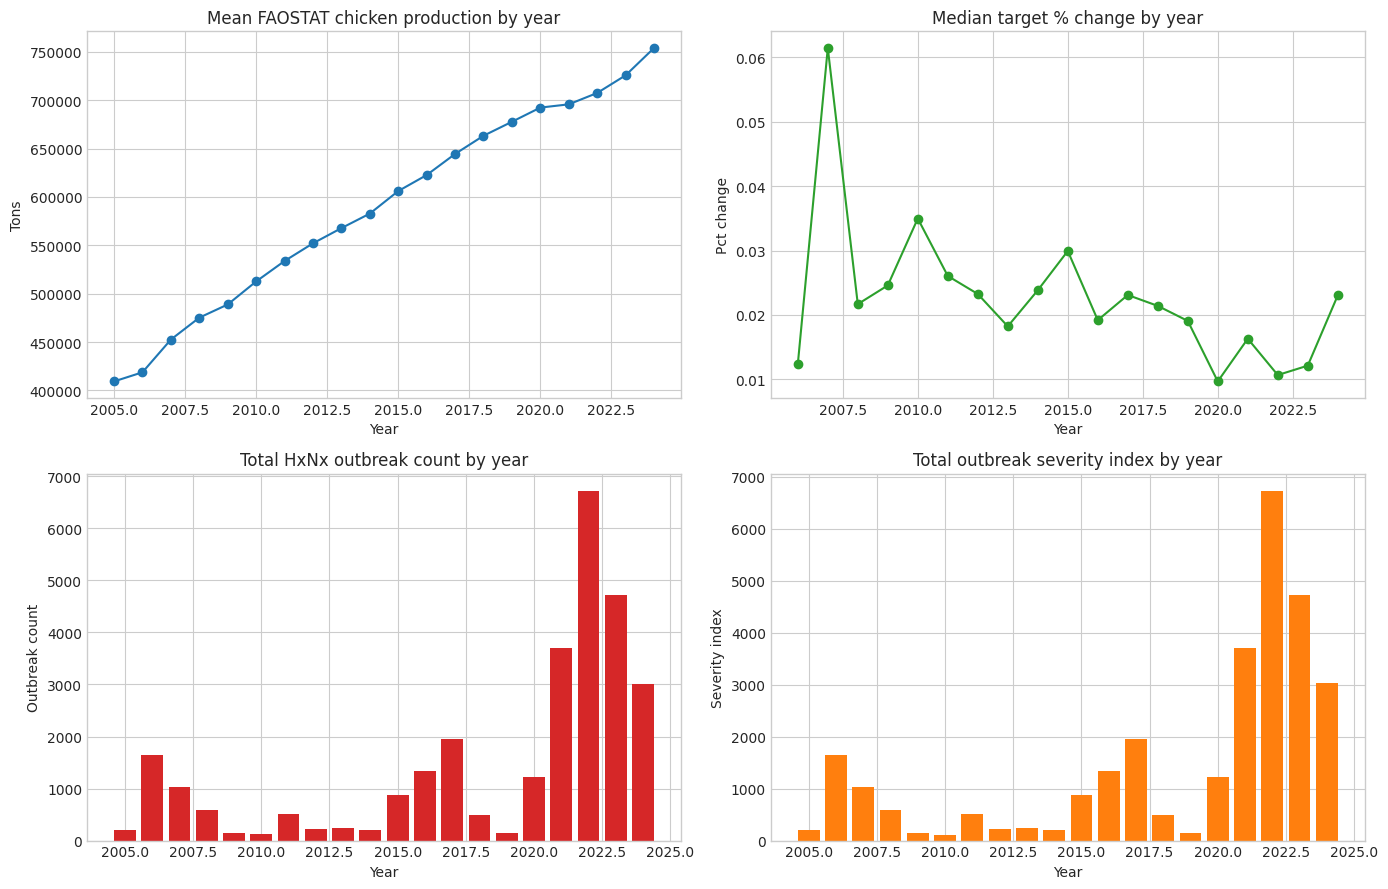

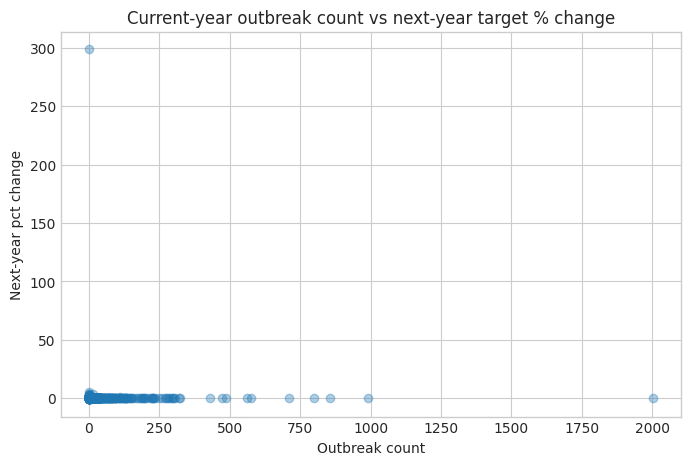

In [5]:
outbreak_year = (
    outbreak_level.groupby(["country_key", "year"], as_index=False)
    .agg(
        outbreak_count=("outbreak_key", "nunique"),
        hxnx_subtype_count=("subtype_disease_name", "nunique"),
        positive_lab_count=("positive_lab_count", "sum"),
        species_diversity=("unique_species_count", "sum"),
        location_spread=("unique_location_count", "sum"),
        severity_index=("severity_proxy", "sum"),
    )
)

fao_target = (
    fao.loc[(fao["Item"] == TARGET_ITEM) & (fao["Element"] == TARGET_ELEMENT)]
    .copy()
    .rename(columns={"Area": "country", "Year": "year", "Value": "target_value"})
)
fao_target = fao_target[["country", "country_key", "year", "target_value", "Unit", "Flag", "Flag Description"]]
fao_target = fao_target.sort_values(["country", "year"]).reset_index(drop=True)
fao_target["series_id"] = fao_target["country"]

fao_target["target_lag_1"] = fao_target.groupby("series_id")["target_value"].shift(1)
fao_target["target_lag_2"] = fao_target.groupby("series_id")["target_value"].shift(2)
fao_target["target_pct_change"] = fao_target.groupby("series_id")["target_value"].pct_change()
fao_target["next_year_target"] = fao_target.groupby("series_id")["target_value"].shift(-1)
fao_target["next_year_pct_change"] = fao_target.groupby("series_id")["target_pct_change"].shift(-1)

merged = fao_target.merge(outbreak_year, on=["country_key", "year"], how="left")
for feature in OUTBREAK_FEATURE_COLUMNS:
    merged[feature] = merged[feature].fillna(0)
    merged[f"{feature}_lag_1"] = merged.groupby("series_id")[feature].shift(1)
    merged[f"{feature}_lag_2"] = merged.groupby("series_id")[feature].shift(2)

merged["target_pct_change_t_plus_1"] = merged.groupby("series_id")["target_pct_change"].shift(-1)
merged["target_pct_change_t_plus_2"] = merged.groupby("series_id")["target_pct_change"].shift(-2)

modeling_table = merged.dropna(subset=["next_year_pct_change", "target_lag_1"]).copy()

cleaning_summary.loc[cleaning_summary["stage"] == "Country-year outbreak feature rows (to be built next)", "rows"] = len(outbreak_year)
display(cleaning_summary)
display_section("FAOSTAT chicken target head", fao_target, rows=12)
display_section("Country-year outbreak features", outbreak_year.sort_values(["year", "outbreak_count"], ascending=[True, False]), rows=12)
display_section(
    "Merged modeling table head",
    modeling_table[
        [
            "country",
            "year",
            "target_value",
            "target_pct_change",
            "next_year_pct_change",
            "outbreak_count",
            "hxnx_subtype_count",
            "positive_lab_count",
            "severity_index",
        ]
    ],
    rows=15,
)

lag_corr_rows = []
for feature in OUTBREAK_FEATURE_COLUMNS:
    for horizon, target_col in [(1, "target_pct_change_t_plus_1"), (2, "target_pct_change_t_plus_2")]:
        pair = merged[[feature, target_col]].dropna()
        lag_corr_rows.append(
            {
                "feature": feature,
                "horizon_years": horizon,
                "observations": len(pair),
                "correlation": pair[feature].corr(pair[target_col]) if len(pair) > 1 else np.nan,
            }
        )
lag_corr_df = pd.DataFrame(lag_corr_rows)
lag_corr_df["abs_correlation"] = lag_corr_df["correlation"].abs()
lag_corr_df = lag_corr_df.sort_values(["horizon_years", "abs_correlation"], ascending=[True, False]).reset_index(drop=True)
display_section("Lag correlations: outbreak features vs future target change", lag_corr_df, rows=20)

year_summary = (
    merged.groupby("year", as_index=False)
    .agg(
        mean_target_value=("target_value", "mean"),
        median_target_pct_change=("target_pct_change", "median"),
        total_outbreak_count=("outbreak_count", "sum"),
        total_severity_index=("severity_index", "sum"),
    )
)

fig, axes = plt.subplots(2, 2, figsize=(14, 9))
axes[0, 0].plot(year_summary["year"], year_summary["mean_target_value"], marker="o")
axes[0, 0].set_title("Mean FAOSTAT chicken production by year")
axes[0, 0].set_xlabel("Year")
axes[0, 0].set_ylabel("Tons")

axes[0, 1].plot(year_summary["year"], year_summary["median_target_pct_change"], marker="o", color="tab:green")
axes[0, 1].set_title("Median target % change by year")
axes[0, 1].set_xlabel("Year")
axes[0, 1].set_ylabel("Pct change")

axes[1, 0].bar(year_summary["year"], year_summary["total_outbreak_count"], color="tab:red")
axes[1, 0].set_title("Total HxNx outbreak count by year")
axes[1, 0].set_xlabel("Year")
axes[1, 0].set_ylabel("Outbreak count")

axes[1, 1].bar(year_summary["year"], year_summary["total_severity_index"], color="tab:orange")
axes[1, 1].set_title("Total outbreak severity index by year")
axes[1, 1].set_xlabel("Year")
axes[1, 1].set_ylabel("Severity index")

plt.tight_layout()
plt.show()

fig, ax = plt.subplots(figsize=(8, 5))
scatter_sample = modeling_table[["outbreak_count", "next_year_pct_change"]].copy()
ax.scatter(scatter_sample["outbreak_count"], scatter_sample["next_year_pct_change"], alpha=0.35)
ax.set_title("Current-year outbreak count vs next-year target % change")
ax.set_xlabel("Outbreak count")
ax.set_ylabel("Next-year pct change")
plt.show()

## 6. Baseline Models, Ridge, and XGBoost

The goal here is not to overfit. It is to test whether outbreak-derived features help enough to beat a simple time-based baseline.

Models in this notebook:

1. **Naive baseline:** next year behaves like this year's percentage change
2. **Ridge regression:** interpretable linear benchmark
3. **XGBoost:** nonlinear benchmark using the same feature table

,model,train_rows,test_rows,test_year_start,test_year_end,mae,rmse,directional_accuracy
0,xgboost,2523,960,2019,2023,0.403734,9.622852,0.659375
1,ridge,2523,960,2019,2023,0.419130,9.657777,0.676042
2,naive_last_change,2523,960,2019,2023,0.750307,13.656757,0.612500


#### Prediction sample

,country,year,next_year_pct_change,naive_last_change,ridge,xgboost
14,Afghanistan,2019,-0.014312,-0.055780,0.050564,0.034809
15,Afghanistan,2020,0.040266,-0.014312,0.048947,0.034482
16,Afghanistan,2021,-0.009577,0.040266,0.044728,0.038743
17,Afghanistan,2022,0.010267,-0.009577,0.048629,0.035421
18,Afghanistan,2023,0.010180,0.010267,0.048153,0.036302
34,Albania,2019,0.051627,-0.253665,0.058296,0.082879
35,Albania,2020,0.083055,0.051627,0.046398,0.040884
36,Albania,2021,0.232873,0.083055,0.043613,0.051652
37,Albania,2022,0.027206,0.232873,0.034661,0.039191
38,Albania,2023,-0.319964,0.027206,0.047658,0.043183


#### Top Ridge coefficients

,coefficient,abs_coefficient
target_pct_change,-0.007895,0.007895
outbreak_count_lag_2,0.001822,0.001822
severity_index_lag_2,0.001822,0.001822
severity_index_lag_1,-0.001684,0.001684
outbreak_count_lag_1,-0.001684,0.001684
target_lag_2,-0.001554,0.001554
hxnx_subtype_count,-0.001227,0.001227
location_spread,0.000886,0.000886
outbreak_count,0.000884,0.000884
severity_index,0.000884,0.000884


#### Top XGBoost feature importances

,importance
target_value,0.175610
target_lag_1,0.173107
target_lag_2,0.148829
target_pct_change,0.132579
severity_index,0.120135
outbreak_count_lag_1,0.074327
outbreak_count,0.072402
location_spread,0.057226
outbreak_count_lag_2,0.036034
severity_index_lag_2,0.009752


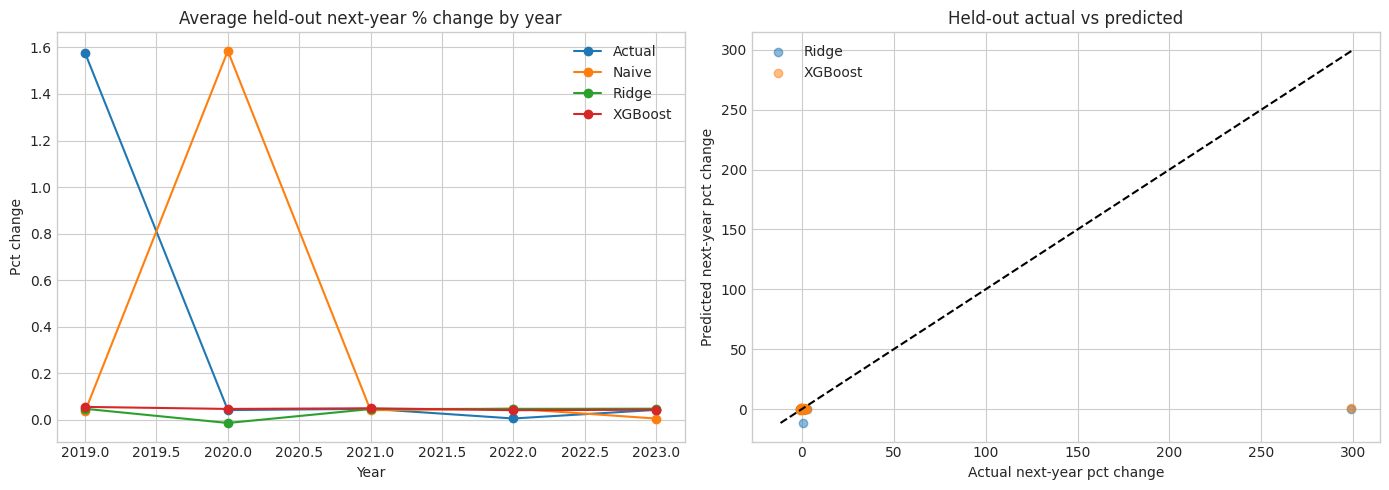

In [6]:
feature_columns = [
    "target_value",
    "target_lag_1",
    "target_lag_2",
    "target_pct_change",
    "outbreak_count",
    "hxnx_subtype_count",
    "positive_lab_count",
    "species_diversity",
    "location_spread",
    "severity_index",
    "outbreak_count_lag_1",
    "outbreak_count_lag_2",
    "positive_lab_count_lag_1",
    "positive_lab_count_lag_2",
    "severity_index_lag_1",
    "severity_index_lag_2",
]

train_df = modeling_table.loc[modeling_table["year"] < TEST_START_YEAR].copy()
test_df = modeling_table.loc[modeling_table["year"] >= TEST_START_YEAR].copy()

X_train = train_df[feature_columns]
X_test = test_df[feature_columns]
y_train = train_df["next_year_pct_change"]
y_test = test_df["next_year_pct_change"]

predictions = {
    "naive_last_change": test_df["target_pct_change"].fillna(0).to_numpy(),
}

ridge = Pipeline(
    [
        ("imputer", SimpleImputer(strategy="constant", fill_value=0.0)),
        ("scaler", StandardScaler()),
        ("model", RidgeCV(alphas=np.logspace(-3, 3, 13))),
    ]
)
ridge.fit(X_train, y_train)
predictions["ridge"] = ridge.predict(X_test)

xgboost_model = Pipeline(
    [
        ("imputer", SimpleImputer(strategy="constant", fill_value=0.0)),
        (
            "model",
            XGBRegressor(
                n_estimators=120,
                max_depth=3,
                learning_rate=0.05,
                subsample=0.9,
                colsample_bytree=0.9,
                objective="reg:squarederror",
                tree_method="hist",
                device="cpu",
                n_jobs=4,
                random_state=42,
            ),
        ),
    ]
)
xgboost_model.fit(X_train, y_train)
predictions["xgboost"] = xgboost_model.predict(X_test)

results_rows = []
for model_name, pred in predictions.items():
    results_rows.append(
        {
            "model": model_name,
            "train_rows": len(train_df),
            "test_rows": len(test_df),
            "test_year_start": int(test_df["year"].min()),
            "test_year_end": int(test_df["year"].max()),
            "mae": mean_absolute_error(y_test, pred),
            "rmse": root_mean_squared_error(y_test, pred),
            "directional_accuracy": directional_accuracy(y_test, pred),
        }
    )
results_df = pd.DataFrame(results_rows).sort_values("rmse").reset_index(drop=True)
display(results_df)

prediction_frame = test_df[["country", "year", "next_year_pct_change"]].copy()
for model_name, pred in predictions.items():
    prediction_frame[model_name] = pred

display_section("Prediction sample", prediction_frame, rows=20)

ridge_coef_df = (
    pd.Series(ridge.named_steps["model"].coef_, index=feature_columns)
    .rename("coefficient")
    .to_frame()
)
ridge_coef_df["abs_coefficient"] = ridge_coef_df["coefficient"].abs()
ridge_coef_df = ridge_coef_df.sort_values("abs_coefficient", ascending=False)

xgb_importance_df = (
    pd.Series(xgboost_model.named_steps["model"].feature_importances_, index=feature_columns)
    .rename("importance")
    .to_frame()
    .sort_values("importance", ascending=False)
)

display_section("Top Ridge coefficients", ridge_coef_df, rows=10)
display_section("Top XGBoost feature importances", xgb_importance_df, rows=10)

yearly_predictions = (
    prediction_frame.groupby("year", as_index=False)
    .agg(
        actual=("next_year_pct_change", "mean"),
        naive_last_change=("naive_last_change", "mean"),
        ridge=("ridge", "mean"),
        xgboost=("xgboost", "mean"),
    )
)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].plot(yearly_predictions["year"], yearly_predictions["actual"], marker="o", label="Actual")
axes[0].plot(yearly_predictions["year"], yearly_predictions["naive_last_change"], marker="o", label="Naive")
axes[0].plot(yearly_predictions["year"], yearly_predictions["ridge"], marker="o", label="Ridge")
axes[0].plot(yearly_predictions["year"], yearly_predictions["xgboost"], marker="o", label="XGBoost")
axes[0].set_title("Average held-out next-year % change by year")
axes[0].set_xlabel("Year")
axes[0].set_ylabel("Pct change")
axes[0].legend()

axes[1].scatter(y_test, predictions["ridge"], alpha=0.5, label="Ridge")
axes[1].scatter(y_test, predictions["xgboost"], alpha=0.5, label="XGBoost")
line_min = min(y_test.min(), predictions["ridge"].min(), predictions["xgboost"].min())
line_max = max(y_test.max(), predictions["ridge"].max(), predictions["xgboost"].max())
axes[1].plot([line_min, line_max], [line_min, line_max], linestyle="--", color="black")
axes[1].set_title("Held-out actual vs predicted")
axes[1].set_xlabel("Actual next-year pct change")
axes[1].set_ylabel("Predicted next-year pct change")
axes[1].legend()

plt.tight_layout()
plt.show()

## 7. Findings and Next Steps

This last section turns the notebook outputs into a concise readout.

In [7]:
best_model = results_df.iloc[0]
strongest_corr = lag_corr_df.iloc[0]
top_ridge_feature = ridge_coef_df.index[0]
top_xgb_feature = xgb_importance_df.index[0]

display(
    Markdown(
        f"""
### Notebook v1 takeaway

- **Target reality:** the FAOSTAT extract does **not** contain price. This notebook therefore predicts **next-year chicken production % change** as a proxy target.
- **Country reconciliation:** {int(country_comparison['direct_match'].sum())} of {len(country_comparison)} FAOSTAT country names have a direct standardized key match to WAHIS.
- **Outbreak scope:** the `HxNx` filter keeps **{len(wahis_hxnx):,}** WAHIS rows, which collapse to **{len(outbreak_level):,}** outbreak-level records and **{len(outbreak_year):,}** country-year feature rows.
- **Best held-out model:** **{best_model["model"]}** with MAE **{best_model["mae"]:.4f}**, RMSE **{best_model["rmse"]:.4f}**, and directional accuracy **{best_model["directional_accuracy"]:.3f}**.
- **Most informative linear signal:** `{top_ridge_feature}`.
- **Most informative nonlinear signal:** `{top_xgb_feature}`.
- **Strongest simple lag relationship:** `{strongest_corr["feature"]}` against target change at **t+{int(strongest_corr["horizon_years"])}** with correlation **{strongest_corr["correlation"]:.4f}**.

### Recommended next steps

1. Replace the FAOSTAT proxy target with a true poultry price series if your end goal is market price prediction.
2. Expand the country alias map for the unmatched FAOSTAT names shown above before doing country-specific interpretation.
3. Try richer outbreak severity definitions, for example positive labs plus duration plus subtype weighting.
4. Compare the current all-country model against country-cluster or regional models, since sensitivity likely differs by geography.
5. If the goal stays yearly, add simpler benchmark features such as multi-year rolling averages and volatility.
        """
    )
)


### Notebook v1 takeaway

- **Target reality:** the FAOSTAT extract does **not** contain price. This notebook therefore predicts **next-year chicken production % change** as a proxy target.
- **Country reconciliation:** 163 of 201 FAOSTAT country names have a direct standardized key match to WAHIS.
- **Outbreak scope:** the `HxNx` filter keeps **45,183** WAHIS rows, which collapse to **44,629** outbreak-level records and **903** country-year feature rows.
- **Best held-out model:** **xgboost** with MAE **0.4037**, RMSE **9.6229**, and directional accuracy **0.659**.
- **Most informative linear signal:** `target_pct_change`.
- **Most informative nonlinear signal:** `target_value`.
- **Strongest simple lag relationship:** `hxnx_subtype_count` against target change at **t+1** with correlation **-0.0068**.

### Recommended next steps

1. Replace the FAOSTAT proxy target with a true poultry price series if your end goal is market price prediction.
2. Expand the country alias map for the unmatched FAOSTAT names shown above before doing country-specific interpretation.
3. Try richer outbreak severity definitions, for example positive labs plus duration plus subtype weighting.
4. Compare the current all-country model against country-cluster or regional models, since sensitivity likely differs by geography.
5. If the goal stays yearly, add simpler benchmark features such as multi-year rolling averages and volatility.
        